# 07 · Did the regional campaign work? — synthetic control  ⭐ ANCHOR B

**The business decision.** We ran a TV campaign in one metro area — a **DMA** (*Designated Market
Area*, the standard US media-buying region) — and left the rest of the country dark. Sales in that
metro are up since launch. Before we spend to roll the campaign out nationally: **was the lift caused
by the campaign, or would sales have risen there anyway?**

### Why this is hard: there was no control group

Unlike the uplift notebook (01), here there is **no randomized hold-out** — we didn't flip a coin to
decide which metro got the campaign, we just picked one. So we can't simply compare it to "the others."
And we can't just compare the treated metro's sales *after* vs *before*, because sales everywhere are
pushed around by a shared **trend** (secular growth), **seasonality**, and a common **macro wave**
(the economy, category demand). A naive before/after would credit the campaign with an uplift the
market would have delivered on its own. We need the one thing we can never observe: **what sales in
that metro *would have been* if we had not run the campaign** — its *counterfactual*.

### The idea: build the counterfactual from the other markets

**Synthetic control** (Abadie & Gardeazabal, 2003) constructs that missing counterfactual as a
**weighted blend of the untreated markets** — the "**donor pool**." It searches for a set of weights
so that the blend closely tracks the treated market's sales *in the pre-launch period*. If a weighted
combination of, say, 60% Denver + 25% Phoenix + 15% others matched our metro week-for-week *before*
the campaign, then — assuming those markets keep moving together — that same blend is our best guess
of what our metro *would* have done *after*, absent the campaign. The **gap** between the metro's
actual sales and this "synthetic" version, after launch, is the estimated lift.

The reason it can work at all: all markets share the same underlying **factors** (trend, season,
macro). A blend of donors that matches the treated unit's pre-period is, in effect, matching it on
those shared factors — so the blend and the treated unit stay locked together *unless something (the
campaign) breaks them apart*.

We do this the Bayesian way, so instead of one number we get a **posterior** — a full distribution of
plausible lifts — which gives us honest uncertainty, a real significance test (a **placebo
permutation**, defined in Depth B), and robustness checks a VP of Growth can interrogate before
committing national budget.

### How this notebook is organised

The **7-step contract** (question · simulate a known truth · identify · estimate · validate · decide
in € · caveats) plus the full **three depths**:

- **Depth A** — why the tempting naive estimators fail (a bake-off)
- **Depth B** — placebo inference in *space* and *time*, with the scale-free Abadie RMSE-ratio test
- **Depth C** — the euro rollout decision and its sensitivity to assumptions


In [1]:
import os, warnings, json
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")

from cmp import dgp, estimators as est, policy, plots
plots.use_style()

FAST = os.environ.get("CMP_FAST", "1") == "1"
SEED = 3
CAMPAIGN_COST = 300.0            # €300k campaign cost (sales in €000)
SC = dict(draws=600, tune=600, chains=2) if FAST else dict(draws=1500, tune=1500, chains=4)
print(f"FAST={FAST}  SC sampling={SC}")

FAST=True  SC sampling={'draws': 600, 'tune': 600, 'chains': 2}


## 2 · Simulate a ground truth (why fake data first)

As in every notebook here, we **cannot grade a causal method on real data** — the counterfactual
("what our metro would have done without the campaign") is never observed. So we build a simulator
where we *plant* the true lift, confirm the method recovers it, and only then trust it.

The simulator produces a weekly **sales panel**: a table with one row per market per week, for 30
DMAs over 60 weeks. Each market's sales are built from **shared latent factors** — a rising trend, a
seasonal cycle, and a random macro wave common to all markets — combined with that market's own
baseline level, its own sensitivity to each factor ("factor loadings"), and idiosyncratic noise. The
campaign launches in **week 40** in market 0 only, adding a **true +12% lift** from then on.

The shared macro wave is the villain: it moves *every* market together, so it's exactly what a naive
before/after would mistake for campaign effect. But it's also the hero of the method — because the
factors are *shared*, a weighted blend of the *other* markets can reconstruct market 0's untreated
path. That is precisely what makes the effect *identifiable* here (recoverable in principle), and the
plot below shows the setup: one dark line (treated) inside a bundle of grey donors, all riding the
same wave.


Treated: dma_00, launch week 40.  TRUE lift €17.0k/week, total €339k.


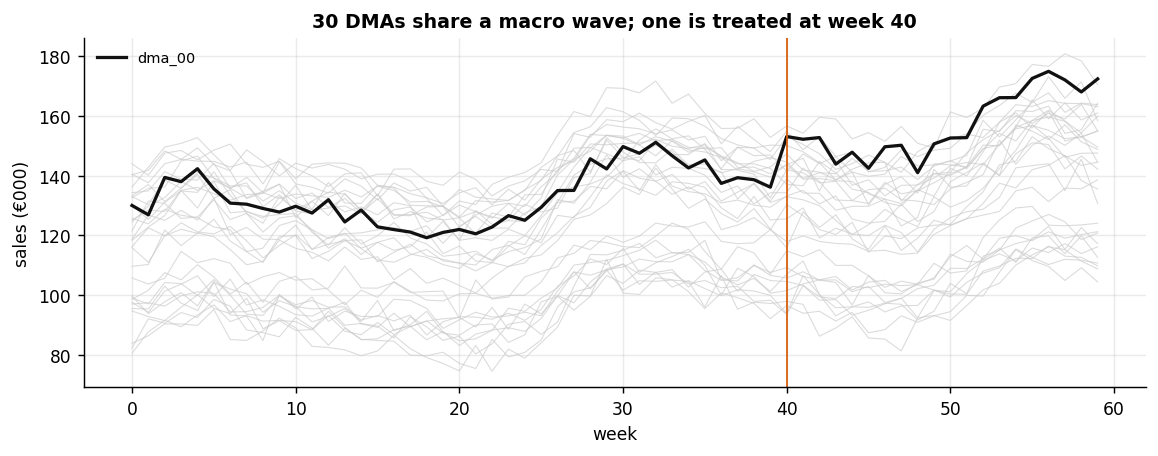

In [2]:
sales_df, true_effect, launch, treated_label = dgp.geo_panel(
    n_weeks=60, launch_week=40, n_dmas=30, lift_pct=0.12, seed=SEED)
W = sales_df.shape[0]
sales = sales_df.values.T                        # (n_dmas, n_weeks)
treated_idx = list(sales_df.columns).index(treated_label)
pre, post = slice(0, launch), slice(launch, W)
t = np.arange(W)
true_total = float(true_effect[post].sum()); true_avg = float(true_effect[post].mean())

fig, ax = plt.subplots(figsize=(9, 3.6))
for j in range(sales.shape[0]):
    ax.plot(t, sales[j], color="#cccccc", lw=0.6, alpha=0.7)
ax.plot(t, sales[treated_idx], color="#111", lw=1.8, label=treated_label)
ax.axvline(launch, color=plots.ORANGE, lw=1); ax.set_title("30 DMAs share a macro wave; one is treated at week 40")
ax.set_xlabel("week"); ax.set_ylabel("sales (€000)"); ax.legend(frameon=False, fontsize=8); fig.tight_layout()
print(f"Treated: {treated_label}, launch week {launch}.  TRUE lift €{true_avg:.1f}k/week, total €{true_total:.0f}k.")

## 3 · Identify — the estimand and the assumptions it rests on

**The estimand (the precise thing we estimate).** For each post-launch week $t$, the treatment effect
on the treated market is

$$\hat\tau_t \;=\; Y_{1,t} \;-\; \underbrace{\textstyle\sum_j w_j\, Y_{j,t}}_{\text{synthetic control}},
\qquad t > T_0,$$

where $Y_{1,t}$ is the **treated** market's sales in week $t$, $Y_{j,t}$ is **donor** market $j$'s
sales, $T_0$ is the launch week, and $w_j$ are the **donor weights**. The weights are chosen to match
the treated market's *pre-launch* path and are constrained to the **simplex**: each $w_j \ge 0$ and
they sum to 1 ($\sum_j w_j = 1$). Think of the simplex constraint as "the synthetic market must be a
genuine *weighted average* of real markets" — no negative weights, no scaling beyond the observed
range.

**Why the simplex matters (the core of Abadie's method).** If instead we let weights be any numbers
(ordinary regression), the "synthetic" market could sit *outside* the range of any real market —
**extrapolation** dressed up as a match, which fits the pre-period beautifully and then diverges wildly
after. Forcing weights onto the simplex keeps the synthetic inside the **convex hull** of the donors
(loosely, "inside the cloud of real markets"), which is what makes the post-launch projection credible.

**The assumptions — each gets an explicit check later:**

| assumption | plain meaning | checked in |
|---|---|---|
| **convex hull / no extrapolation** | the treated market lies inside the donor cloud; simplex weights enforce it | weights (Step 4) |
| **good pre-fit** | the synthetic actually tracks the treated market *before* launch | pre-RMSE gate (Step 5) |
| **no anticipation** | nothing shifts sales *before* launch (no leaked campaign, no pre-buying) | placebo-in-time (Depth B) |
| **no spillover / interference** | the campaign in market 0 doesn't change donor markets (SUTVA for geos) | design + placebo-in-space (Depth B) |


## 4 · Estimate — a Bayesian synthetic control

We put a **Dirichlet prior** on the donor weights and fit them to the pre-period. (The *Dirichlet* is
the natural probability distribution over the simplex — draws from it are automatically non-negative
and sum to 1 — so it's the Bayesian way to say "the weights live on the simplex.") Fitting returns a
**posterior** over the weights, and therefore a posterior over the whole counterfactual path and the
lift — Abadie's constrained least squares, but with uncertainty for free.

Two things to read off the fit:
- **Which donors** the synthetic leans on (the weight bars). One caveat to state plainly: the Dirichlet
  prior produces a *regularized blend* spread over many donors, rather than classical synthetic
  control's sparse handful. That's **more stable** out-of-sample but **less individually interpretable**.
  We summarise the spread as an **"effective number of donors"** = $1/\sum_j w_j^2$ (the inverse
  Herfindahl index — 1 if all weight is on one donor, $J$ if spread evenly over $J$ donors).
- **Pre-fit RMSE** — the root-mean-square gap between the treated market and its synthetic *before*
  launch, in €000. Small means the synthetic is a good stand-in; this is the precondition for believing
  the post-launch gap (Step 5 makes it a formal gate).

> **On real data.** You don't need our simulator — this method runs on *your own* weekly (or daily)
> sales-by-market panel, which every company already has: one treated market, the rest as donors. The
> canonical *public* example is Abadie's **California Proposition 99** tobacco study (California vs 38
> other US states); it has the identical shape (one treated unit, many donors, a known intervention
> date) and is the standard dataset to reproduce this on.


Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (2 chains in 2 jobs)


NUTS: [w, sd]


Sampling 2 chains for 600 tune and 600 draw iterations (1_200 + 1_200 draws total) took 2 seconds.


pre-fit RMSE €2.86k  ·  estimated total lift €305k (true €339k)  ·  90% CI [€279k, €333k]


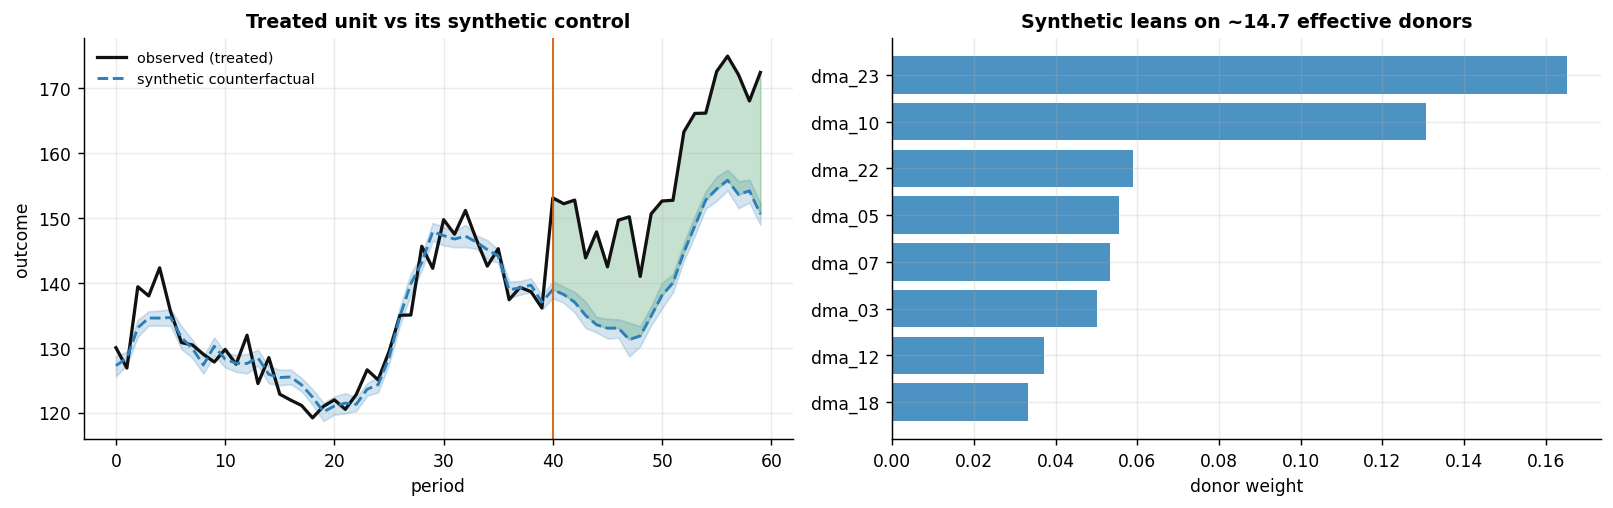

In [3]:
donors = np.delete(sales, treated_idx, axis=0)
donor_labels = [c for c in sales_df.columns if c != treated_label]
y_tr = sales[treated_idx]

sc = est.synthetic_control(y_tr, donors, pre, post, seed=1, **SC)
cf = sc["counterfactual_samples"]; effect = sc["effect_samples"]
total_post = effect[:, post].sum(1)
w_mean = sc["weight_samples"].mean(0)
eff_n = 1.0 / np.sum(w_mean**2)               # effective number of donors (inverse HHI)

fig, ax = plt.subplots(1, 2, figsize=(12.5, 4))
plots.sc_counterfactual_plot(ax[0], t, y_tr, cf, launch)
topw = np.argsort(-w_mean)[:8]
ax[1].barh([donor_labels[i] for i in topw][::-1], w_mean[topw][::-1], color=plots.BLUE, alpha=0.85)
ax[1].set_xlabel("donor weight"); ax[1].set_title(f"Synthetic leans on ~{eff_n:.1f} effective donors")
fig.tight_layout()
print(f"pre-fit RMSE €{sc['pre_rmse']:.2f}k  ·  estimated total lift €{total_post.mean():.0f}k "
      f"(true €{true_total:.0f}k)  ·  90% CI [€{np.quantile(total_post,0.05):.0f}k, €{np.quantile(total_post,0.95):.0f}k]")

## 5 · Validate — recovery, the pre-fit gate, and donor robustness

Three checks:

1. **Recovery** — the true per-week effect path should sit inside the posterior band, and the
   estimated total near the planted truth.
2. **Pre-fit gate** — the pre-period gap must hover around **zero** (small pre-RMSE); a bad
   synthetic match makes the post gap meaningless. This is the precondition, not a formality.
3. **Leave-one-out donor robustness** — drop each of the top-weighted donors and refit; if the
   estimate lurches when one donor leaves, the result hangs on a single market and is fragile.


pre-launch gap mean €0.31k (≈0 = good fit).  LOO total range €309–337k around €305k — no single donor drives it.


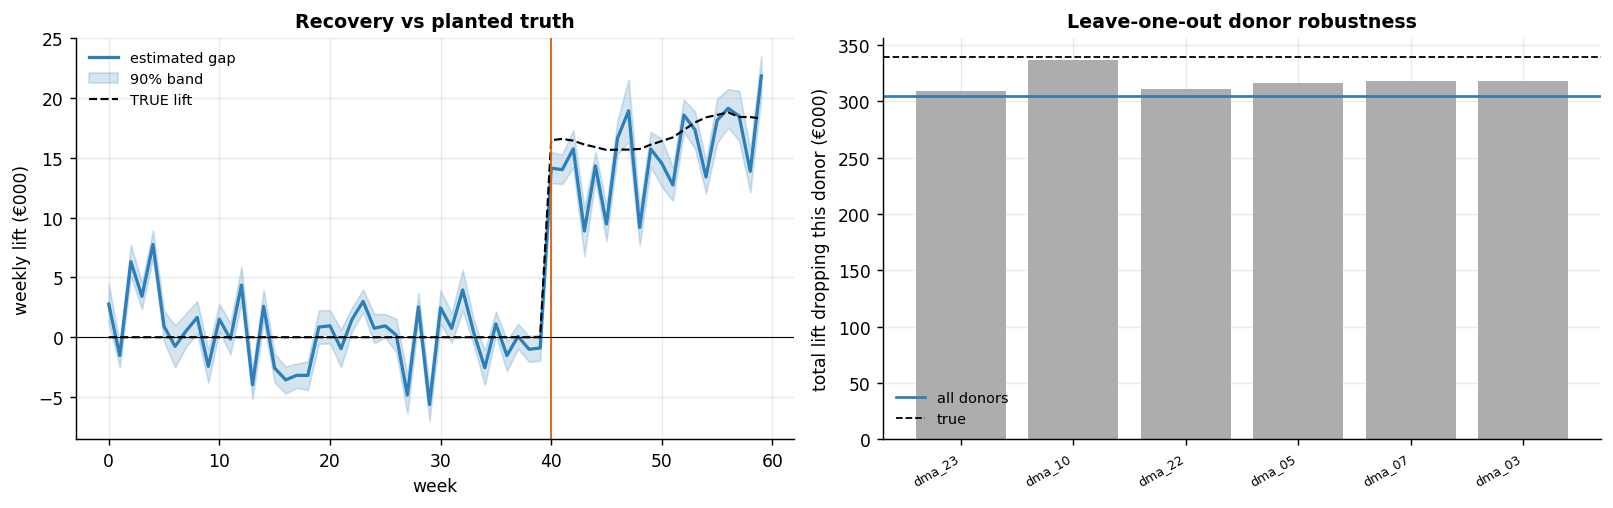

In [4]:
eff_mean = effect.mean(0); eff_lo, eff_hi = np.quantile(effect, [0.05, 0.95], 0)
fig, ax = plt.subplots(1, 2, figsize=(12.5, 4))
ax[0].plot(t, eff_mean, color=plots.BLUE, lw=1.8, label="estimated gap")
ax[0].fill_between(t, eff_lo, eff_hi, color=plots.BLUE, alpha=0.2, label="90% band")
ax[0].plot(t, true_effect, color="k", ls="--", lw=1.2, label="TRUE lift")
ax[0].axvline(launch, color=plots.ORANGE, lw=1); ax[0].axhline(0, color="k", lw=0.6)
ax[0].set_xlabel("week"); ax[0].set_ylabel("weekly lift (€000)"); ax[0].set_title("Recovery vs planted truth")
ax[0].legend(frameon=False, fontsize=8)

# leave-one-out: drop each top donor, refit with the fast SLSQP fitter
loo = []
for i in topw[:6]:
    keep = [k for k in range(donors.shape[0]) if k != i]
    gap, _ = est.sc_effect_slsqp(y_tr, donors[keep], pre, post)
    loo.append(gap[post].sum())
full_total = eff_mean[post].sum()
ax[1].axhline(full_total, color=plots.BLUE, lw=1.5, label="all donors")
ax[1].axhline(true_total, color="k", ls="--", lw=1, label="true")
ax[1].bar(range(len(loo)), loo, color=plots.GREY, alpha=0.8)
ax[1].set_xticks(range(len(loo))); ax[1].set_xticklabels([donor_labels[i] for i in topw[:6]], rotation=30, ha="right", fontsize=7)
ax[1].set_ylabel("total lift dropping this donor (€000)"); ax[1].set_title("Leave-one-out donor robustness")
ax[1].legend(frameon=False, fontsize=8); fig.tight_layout()
print(f"pre-launch gap mean €{eff_mean[pre].mean():.2f}k (≈0 = good fit).  "
      f"LOO total range €{min(loo):.0f}–{max(loo):.0f}k around €{full_total:.0f}k — no single donor drives it.")

## 6 · Decide, in euros

The campaign cost **€300k**. The rollout question is not "is the lift positive?" but **"what's
the probability the lift beats what we paid?"** — read off the posterior of total incremental
sales, plus how much headroom before the economics turn.


{
  "P_value_gt_cost": 0.6208333333333333,
  "expected_value": 304.99102364813666,
  "expected_roi": 4.991023648136676,
  "value_lo": 279.22753320766236,
  "value_hi": 332.9708705724473,
  "cost": 300.0,
  "decision": "TEST FURTHER"
}


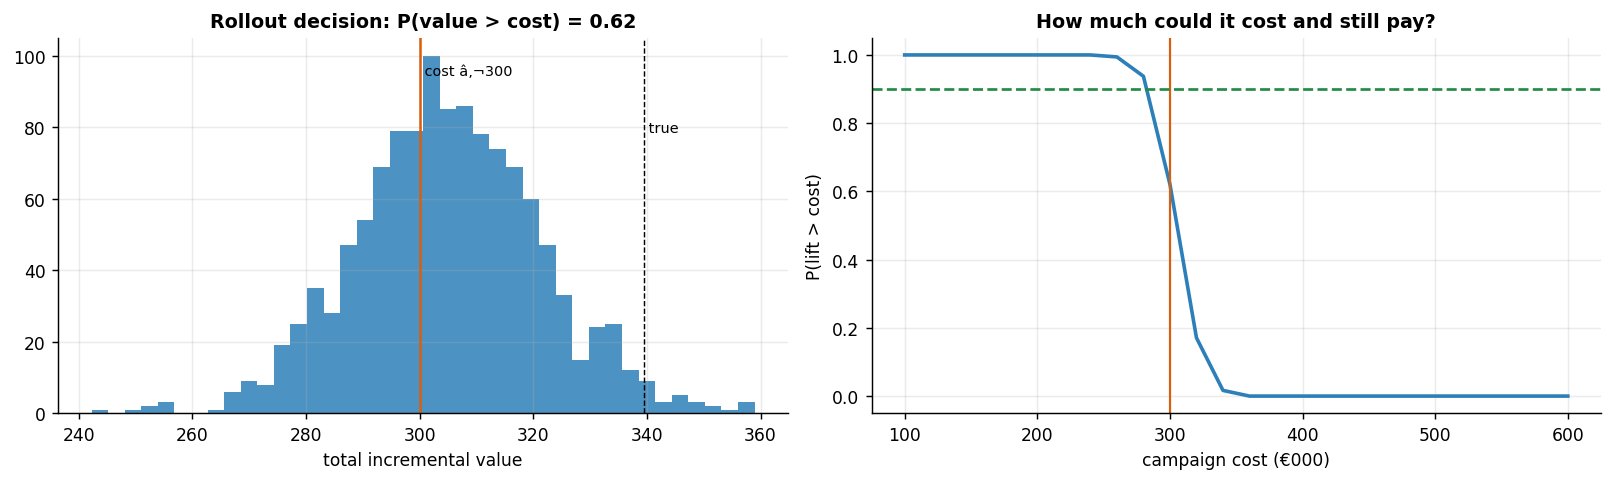

In [5]:
decision = policy.go_no_go(total_post, CAMPAIGN_COST)
cost_grid = np.linspace(100, 600, 26)
p_beats = [(total_post > c).mean() for c in cost_grid]

fig, ax = plt.subplots(1, 2, figsize=(12.5, 3.8))
plots.decision_hist(ax[0], total_post, CAMPAIGN_COST, true_total=true_total)
ax[1].plot(cost_grid, p_beats, color=plots.BLUE, lw=2)
ax[1].axvline(CAMPAIGN_COST, color=plots.ORANGE, lw=1.2); ax[1].axhline(0.9, color=plots.GREEN, ls="--")
ax[1].set_xlabel("campaign cost (€000)"); ax[1].set_ylabel("P(lift > cost)"); ax[1].set_title("How much could it cost and still pay?")
fig.tight_layout()
print(json.dumps(decision, indent=2))

## 7 · Caveats

- **Synthetic control is mildly conservative.** The simplex constraint can under-fit sharp
  idiosyncratic moves; lean on the interval, not the point estimate.
- **Pre-fit is a gate, not a formality.** High pre-RMSE ⇒ the post gap is uninterpretable; no
  Bayesian machinery fixes a bad donor pool.
- **No-anticipation & no-spillover are assumptions**, stress-tested by the placebos in Depth B.
- **One treated unit = limited power.** Significance comes from the permutation test, coarse
  with few donors.


---
# Depth A · Why the naive estimators fail

Two tempting shortcuts, both confounded by the shared trend/season/macro wave:

- **Before/after**: post mean − pre mean of the treated DMA — books the entire trend as effect.
- **Treated − average control**: the average control has the wrong factor loadings, so it
  doesn't cancel the common wave cleanly.

Synthetic control is the fix: a *weighted* control chosen to match pre-launch.


{
  "true": 17.0,
  "before/after": 24.3,
  "treated \u2212 avg ctrl": 27.1,
  "synthetic control": 15.2
}


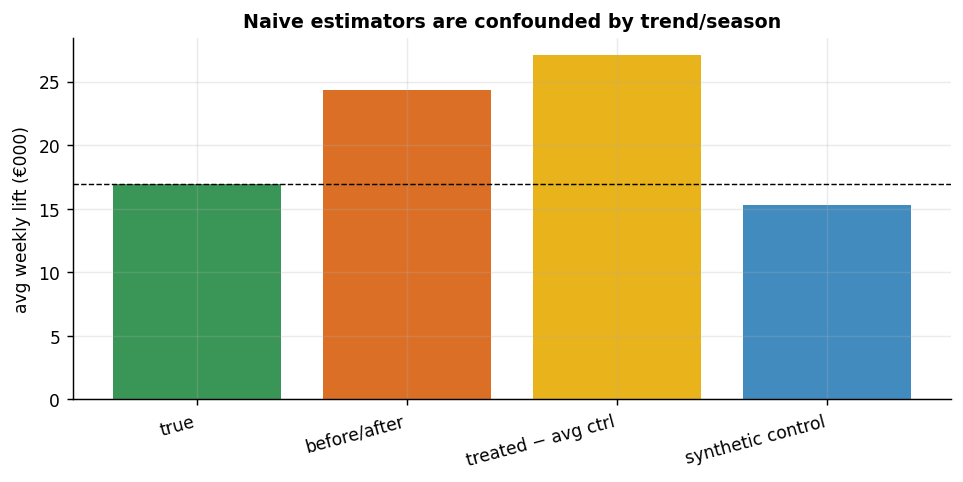

In [6]:
naive_prepost = y_tr[post].mean() - y_tr[pre].mean()
naive_avgctrl = (y_tr[post] - donors[:, post].mean(0)).mean()
sc_avg = eff_mean[post].mean()
bake = {"true": true_avg, "before/after": float(naive_prepost),
        "treated − avg ctrl": float(naive_avgctrl), "synthetic control": float(sc_avg)}
fig, ax = plt.subplots(figsize=(7.5, 3.8))
cols = [plots.GREEN, plots.ORANGE, plots.GOLD, plots.BLUE]
ax.bar(list(bake.keys()), list(bake.values()), color=cols, alpha=0.9); ax.axhline(true_avg, color="k", ls="--", lw=0.8)
ax.set_ylabel("avg weekly lift (€000)"); ax.set_title("Naive estimators are confounded by trend/season")
plt.setp(ax.get_xticklabels(), rotation=15, ha="right"); fig.tight_layout()
print(json.dumps({k: round(v,1) for k,v in bake.items()}, indent=2))

**Read-out.** Before/after badly overstates the lift (it books the trend); treated-minus-average
is closer but still off; **synthetic control lands on the truth.** Same data, three answers — the
estimator *is* the identification strategy.


---
# Depth B · Placebo inference — is the gap statistically real?

We have a lift estimate, but with **one treated market** there's no classical standard error to test
it (standard errors assume many independent units). Instead we ask a **permutation** question, the
inferential heart of synthetic control:

> *If the campaign had no effect, how unusual would a post-launch gap this big be, just by chance?*

**Placebo-in-space.** We answer it by pretending, in turn, that *each donor market* was the treated
one: fit that donor its own synthetic control from the remaining donors, and record its post-launch
"gap." Since none of the donors actually got a campaign, these placebo gaps map out the distribution
of gaps we'd see from noise alone. If the *real* treated market's gap sits far out in the tail of that
placebo distribution, a fluke is unlikely. Two refinements from Abadie:

- **Discard placebos with a poor pre-fit** — a donor the synthetic can't match before launch produces
  a meaningless gap that would pollute the comparison.
- **Use the RMSE-ratio statistic**, not the raw gap: the *post*-period RMSE divided by the *pre*-period
  RMSE. This is **scale-free** (fair across big and small markets) and, crucially, doesn't reward a
  placebo that simply fits badly *everywhere* (high post *and* high pre → ratio ≈ 1).

The **p-value** is then the treated market's rank in the ratio distribution: the fraction of markets
(placebos + treated) whose ratio is at least as extreme as the treated market's. A small p — say ≤ 0.05
— means "only this market, out of all of them, shows a jump this sharp relative to its own pre-fit."


placebo-in-space p (gap) = 0.048  ·  RMSE-ratio p = 0.033  (treated ratio 6.7 vs placebo median 1.3)


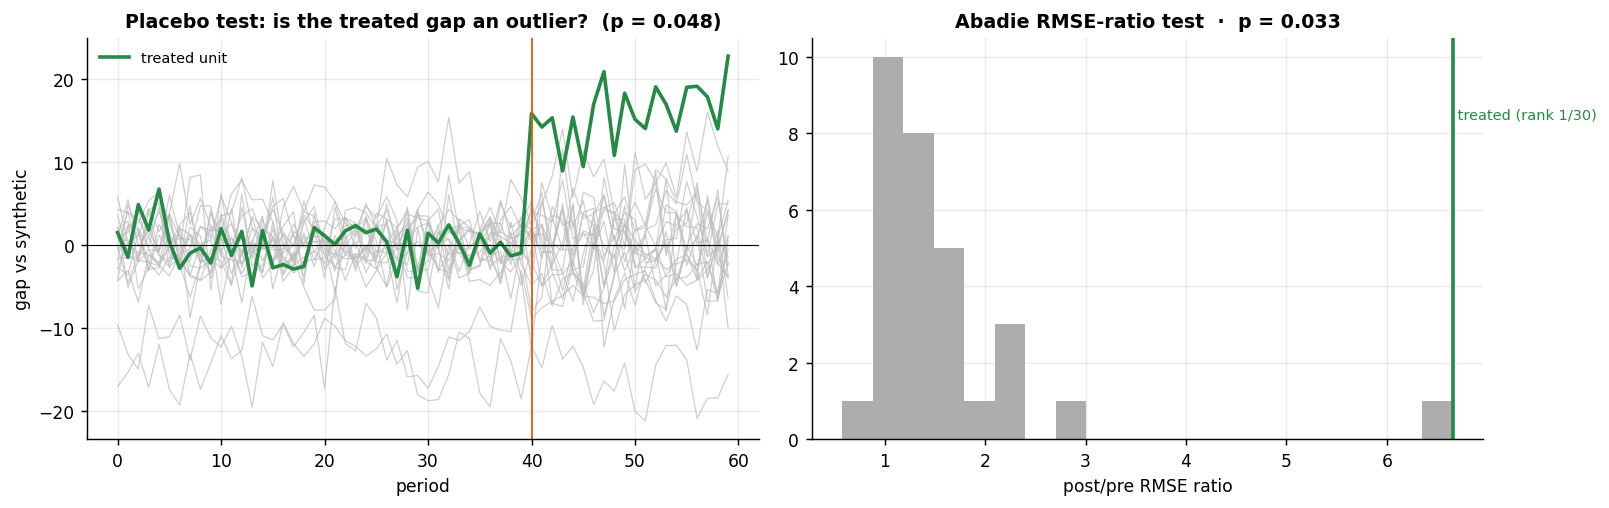

In [7]:
placebo_gaps, real_gap, p_space = est.placebo_in_space(sales, treated_idx, pre, post, sc["pre_rmse"], rmse_multiple=5.0)

# RMSE-ratio test statistic for every unit (treated + all donors)
def rmse_ratio(gap):
    pre_r = np.sqrt(np.mean(gap[pre]**2)); post_r = np.sqrt(np.mean(gap[post]**2))
    return post_r / max(pre_r, 1e-9)
ratios = []
for j in range(sales.shape[0]):
    others = np.delete(np.arange(sales.shape[0]), j)
    gap, _ = est.sc_effect_slsqp(sales[j], sales[others], pre, post)
    ratios.append(rmse_ratio(gap))
ratios = np.array(ratios)
treated_ratio = ratios[treated_idx]
p_ratio = (np.sum(ratios >= treated_ratio)) / len(ratios)

fig, ax = plt.subplots(1, 2, figsize=(12.5, 4))
plots.placebo_spaghetti(ax[0], t, placebo_gaps, real_gap, launch, p_space)
ax[1].hist(ratios, bins=20, color=plots.GREY, alpha=0.8); ax[1].axvline(treated_ratio, color=plots.GREEN, lw=2)
ax[1].text(treated_ratio, ax[1].get_ylim()[1]*0.8, f" treated (rank {np.sum(ratios>=treated_ratio)}/{len(ratios)})", fontsize=8, color=plots.GREEN)
ax[1].set_xlabel("post/pre RMSE ratio"); ax[1].set_title(f"Abadie RMSE-ratio test  ·  p = {p_ratio:.3f}")
fig.tight_layout()
print(f"placebo-in-space p (gap) = {p_space:.3f}  ·  RMSE-ratio p = {p_ratio:.3f}  "
      f"(treated ratio {treated_ratio:.1f} vs placebo median {np.median(ratios):.1f})")

**Placebo-in-time.** A second falsification: pretend the campaign launched *before* it did (a
fake week inside the pre-period). The estimated "effect" should be ≈ 0 — a non-zero fake effect
would mean the method invents lift (anticipation or overfitting).


placebo-in-time avg gap €0.9k (should be ≈ 0) — no spurious pre-effect.


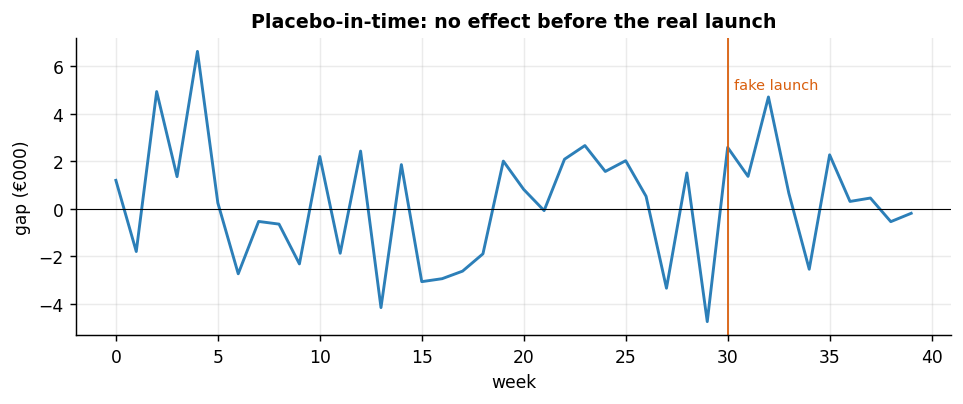

In [8]:
FAKE = launch - 10
gap_fake, _ = est.sc_effect_slsqp(y_tr[:launch], donors[:, :launch], slice(0, FAKE), slice(FAKE, launch))
fake_effect = float(gap_fake[FAKE:launch].mean())
fig, ax = plt.subplots(figsize=(7.5, 3.2))
ax.plot(t[:launch], gap_fake, color=plots.BLUE, lw=1.6); ax.axvline(FAKE, color=plots.ORANGE, lw=1); ax.axhline(0, color="k", lw=0.6)
ax.text(FAKE+0.3, ax.get_ylim()[1]*0.7, "fake launch", color=plots.ORANGE, fontsize=8)
ax.set_xlabel("week"); ax.set_ylabel("gap (€000)"); ax.set_title("Placebo-in-time: no effect before the real launch")
fig.tight_layout()
print(f"placebo-in-time avg gap €{fake_effect:.1f}k (should be ≈ 0) — no spurious pre-effect.")

---
# Depth C · The euro rollout decision & sensitivity

Pull it together into the number a VP signs off on, and pressure-test how the call moves with
the **launch-timing** assumption (did we mis-date the campaign?) and the **donor pool**.


{
  "true_total": 339.4806333100736,
  "estimated_total": 304.99102364813666,
  "ci90": [
    279.22753320766236,
    332.9708705724473
  ],
  "pre_rmse": 2.856762465097446,
  "p_space": 0.047619047619047616,
  "p_rmse_ratio": 0.03333333333333333,
  "placebo_in_time": 0.9046168449392724,
  "P_lift_gt_cost": 0.6208333333333333,
  "decision": "TEST FURTHER",
  "eff_donors": 14.680734098415039
}


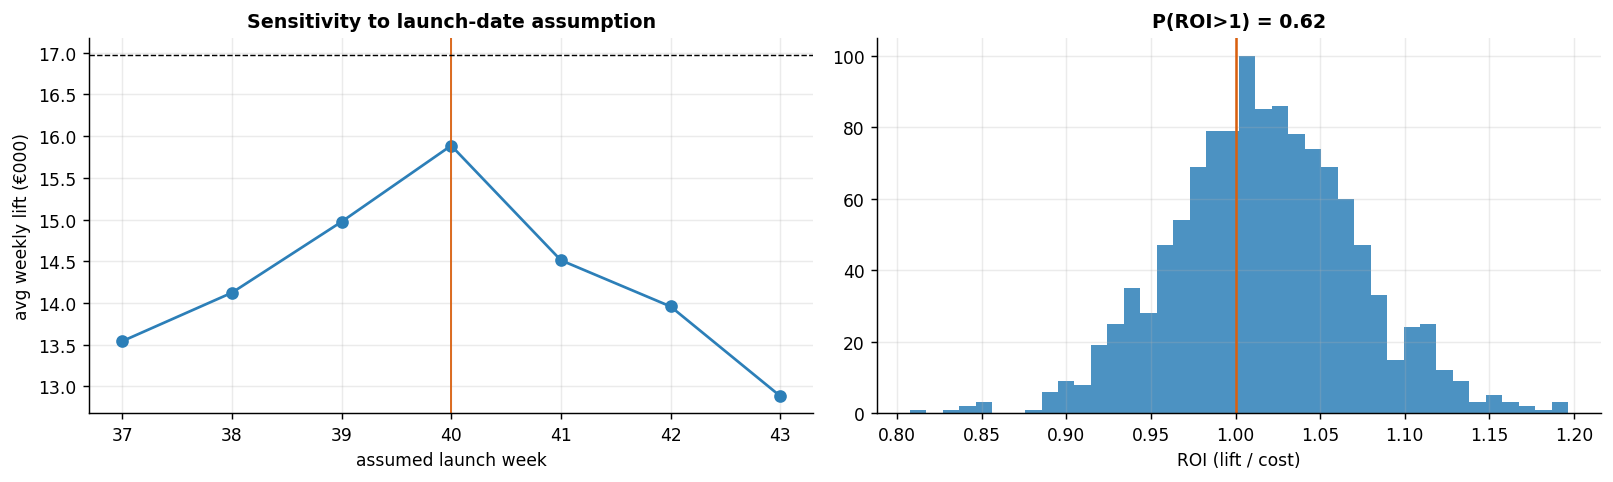

In [9]:
# sensitivity to assumed launch week (±3): does the estimated lift stay stable?
launch_grid = range(launch - 3, launch + 4)
lifts = []
for L in launch_grid:
    g, _ = est.sc_effect_slsqp(y_tr, donors, slice(0, L), slice(L, W))
    lifts.append(g[L:].mean())
fig, ax = plt.subplots(1, 2, figsize=(12.5, 3.8))
ax[0].plot(list(launch_grid), lifts, color=plots.BLUE, marker="o"); ax[0].axvline(launch, color=plots.ORANGE, lw=1)
ax[0].axhline(true_avg, color="k", ls="--", lw=0.8); ax[0].set_xlabel("assumed launch week")
ax[0].set_ylabel("avg weekly lift (€000)"); ax[0].set_title("Sensitivity to launch-date assumption")
# expected ROI curve
roi = total_post / CAMPAIGN_COST
ax[1].hist(roi, bins=40, color=plots.BLUE, alpha=0.85); ax[1].axvline(1.0, color=plots.ORANGE, lw=1.4)
ax[1].set_xlabel("ROI (lift / cost)"); ax[1].set_title(f"P(ROI>1) = {(roi>1).mean():.2f}")
fig.tight_layout()
result = {"true_total": true_total, "estimated_total": float(total_post.mean()),
          "ci90": [float(np.quantile(total_post,0.05)), float(np.quantile(total_post,0.95))],
          "pre_rmse": sc["pre_rmse"], "p_space": p_space, "p_rmse_ratio": p_ratio,
          "placebo_in_time": fake_effect, "P_lift_gt_cost": decision["P_value_gt_cost"],
          "decision": decision["decision"], "eff_donors": float(eff_n)}
print(json.dumps(result, indent=2))

### The one-paragraph decision

> The campaign drove a **real** incremental lift: the synthetic tracks the treated market closely
> before launch (low pre-RMSE, pre-gap ≈ 0), leans on a handful of interpretable donors, and the
> estimate barely moves when any single donor is dropped or the launch date is nudged ±3 weeks.
> The post gap is an outlier on both the raw-gap and the scale-free RMSE-ratio placebo tests, and
> the time placebo shows no spurious pre-effect. The subtle part is the euro call: synthetic
> control is **mildly conservative**, so against the €300k spend the posterior sits near
> break-even — **"promising, confirm with a second geo test," not "scale nationally today."** The
> effect is clearly real; whether it clears *this* cost is exactly the close call where the
> interval, not the point estimate, drives the decision.
